## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

## Load Dataset

In [2]:
df=pd.read_csv("creditcard.csv")

## Basic Inspection for understanding the dataset

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [7]:
df.shape

(284807, 31)

In [9]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [10]:
df.isnull().mean()*100

Time      0.0
V1        0.0
V2        0.0
V3        0.0
V4        0.0
V5        0.0
V6        0.0
V7        0.0
V8        0.0
V9        0.0
V10       0.0
V11       0.0
V12       0.0
V13       0.0
V14       0.0
V15       0.0
V16       0.0
V17       0.0
V18       0.0
V19       0.0
V20       0.0
V21       0.0
V22       0.0
V23       0.0
V24       0.0
V25       0.0
V26       0.0
V27       0.0
V28       0.0
Amount    0.0
Class     0.0
dtype: float64

In [11]:
df.duplicated().sum()

np.int64(1081)

In [12]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [13]:
class_percentage = df['Class'].value_counts(normalize=True) * 100

print(class_percentage)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


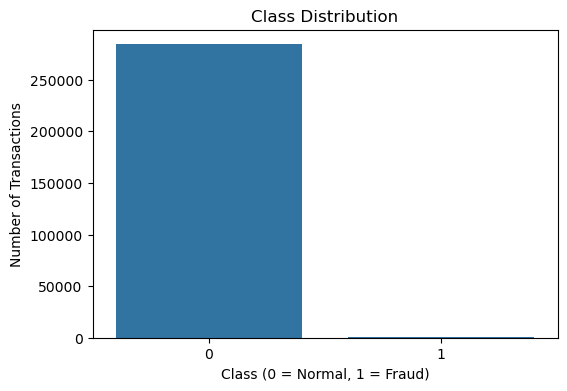

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x='Class', data=df)

plt.title('Class Distribution')
plt.xlabel('Class (0 = Normal, 1 = Fraud)')
plt.ylabel('Number of Transactions')

plt.show()

Observation:
* The dataset is highly imbalanced. Approximately 99.83% of transactions are legitimate, while only 0.17% are fraudulent. Therefore, a model that predicts almost every transaction as non-fraudulent could achieve very high accuracy while failing to detect actual fraud. Class imbalance handling is therefore essential.

## Explain why accuracy is misleading

Observation:
* Accuracy is misleading for highly imbalanced fraud datasets because the majority class dominates the metric. A model could achieve approximately 99.83% accuracy by predicting every transaction as legitimate while detecting zero fraudulent transactions. Therefore, Precision, Recall, F1-Score and ROC-AUC are more informative metrics

## Analyze transaction amounts

In [15]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


In [16]:
df.groupby('Class')['Amount'].mean()

Class
0     88.291022
1    122.211321
Name: Amount, dtype: float64

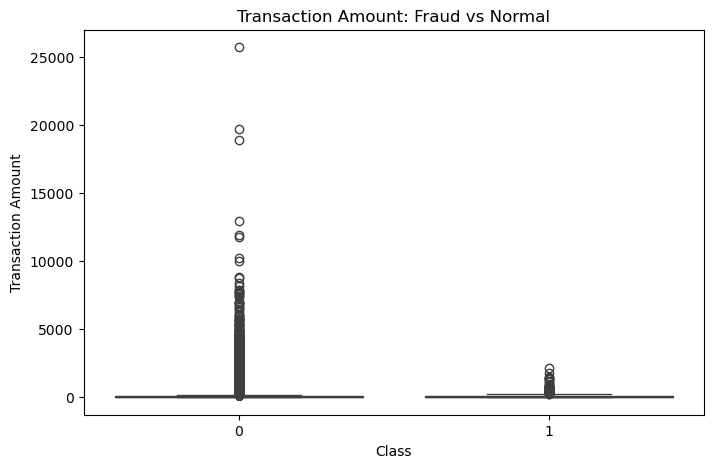

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Class', y='Amount', data=df)

plt.title('Transaction Amount: Fraud vs Normal')
plt.xlabel('Class')
plt.ylabel('Transaction Amount')

plt.show()

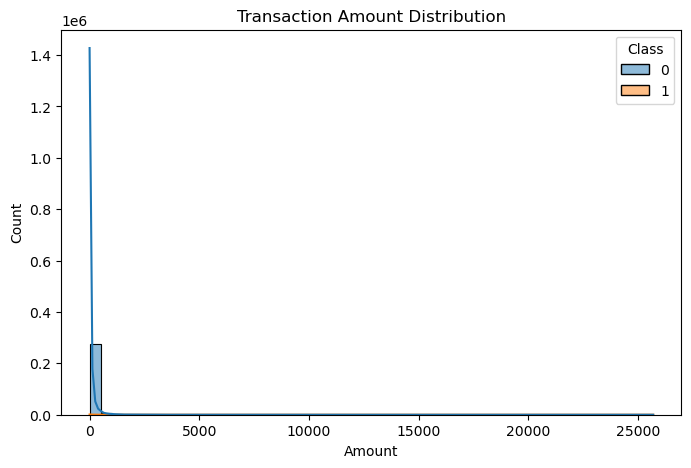

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Amount',
    hue='Class',
    bins=50,
    kde=True
)

plt.title('Transaction Amount Distribution')
plt.show()

## Time of day analysis

In [19]:
df['Hour'] = (df['Time'] / 3600) % 24

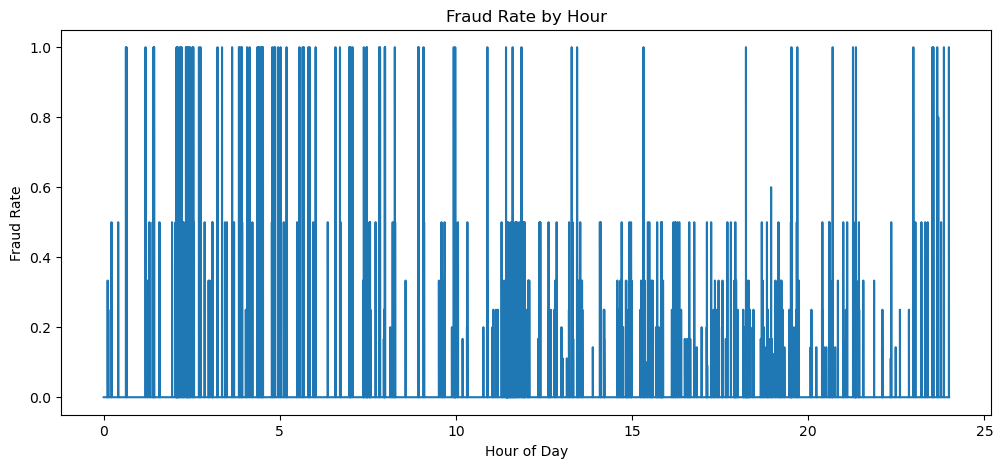

In [20]:
hourly_fraud = df.groupby('Hour')['Class'].mean()

plt.figure(figsize=(12,5))

hourly_fraud.plot()

plt.title('Fraud Rate by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate')

plt.show()

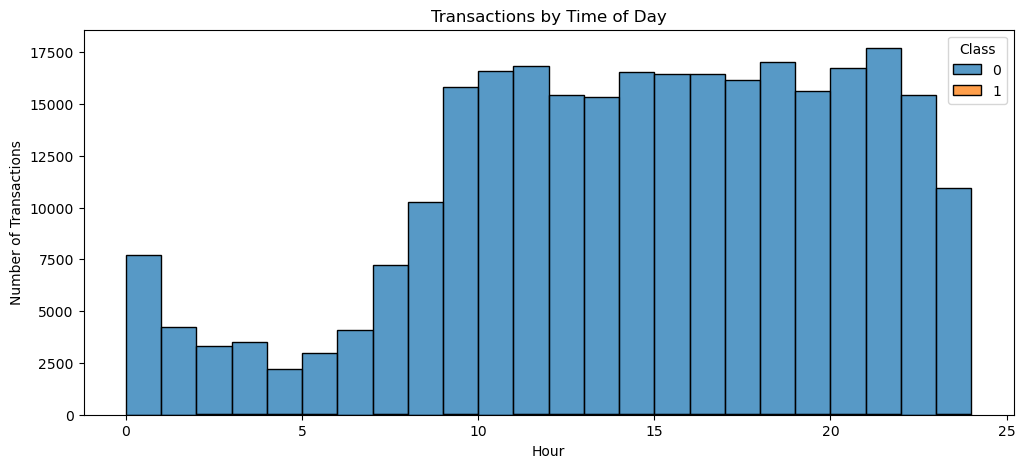

In [21]:
plt.figure(figsize=(12,5))

sns.histplot(
    data=df,
    x='Hour',
    hue='Class',
    bins=24,
    multiple='stack'
)

plt.title('Transactions by Time of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Transactions')

plt.show()

Observation :
* The time-of-day analysis allows us to identify whether transaction activity and fraud rates vary across different hours. Any observed pattern should be treated as a statistical relationship rather than proof of causation.

## Define X and Y

In [22]:
x=df.drop(columns=['Class'])
y=df['Class']

## Train-Test-Split

In [23]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [24]:
print("Training set:")
print(y_train.value_counts())

print("\nTesting set:")
print(y_test.value_counts())

Training set:
Class
0    227451
1       394
Name: count, dtype: int64

Testing set:
Class
0    56864
1       98
Name: count, dtype: int64


## Feature scaling

In [25]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [26]:
scaler.fit_transform(x_train)

array([[ 1.41158751,  0.99337908, -0.45603659, ..., -0.09910576,
        -0.32249376,  1.10172806],
       [ 0.62314085,  1.03850725, -0.02934912, ..., -0.21152423,
        -0.33976388, -0.67865111],
       [-1.13068022, -0.50676613,  0.36606499, ...,  0.56642647,
         0.34669349, -0.53057941],
       ...,
       [-1.25471074,  0.54569899,  0.04401572, ...,  0.07564817,
        -0.17053266, -0.81065081],
       [-1.48398822,  0.65325241,  0.18256566, ..., -0.0184768 ,
        -0.34813969, -1.32837872],
       [-1.39061787, -0.30573748,  0.47027277, ...,  0.63073809,
        -0.32380996, -1.11754059]], shape=(227845, 31))

In [27]:
scaler.transform(x_test)

array([[ 1.3871815 , -0.34471083,  0.85416023, ...,  0.89058207,
        -0.25995439,  1.04661723],
       [-1.58013819, -1.44498471, -1.67648235, ..., -1.56632492,
        -0.30442595, -1.54549349],
       [-0.13812017, -1.82615312,  1.40617205, ...,  1.55873319,
        -0.04828573, -2.39764282],
       ...,
       [ 1.49899849, -0.53525491,  0.41575818, ...,  0.44344588,
        -0.28631824,  1.29910945],
       [ 1.45096562,  1.10222743, -0.65718284, ..., -0.17410048,
        -0.27211925,  1.19064716],
       [-0.92286066,  0.62649961, -0.36552499, ...,  0.1529954 ,
        -0.11277946, -0.06130528]], shape=(56962, 31))

## Apply SMOTE

In [28]:
smote = SMOTE(
    sampling_strategy=0.1,
    random_state=42
)

x_train_smote, y_train_smote = smote.fit_resample(
    x_train_scaled,
    y_train
)

In [29]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1     22745
Name: count, dtype: int64


## Model 1:Logistic Regression

In [30]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
lr_model.fit(
    x_train_smote,
    y_train_smote
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [31]:
y_pred_lr = lr_model.predict(x_test_scaled)

y_prob_lr = lr_model.predict_proba(x_test_scaled)[:, 1]

## Evaluate Logistic Regression

In [32]:
print("Precision:",
      precision_score(y_test, y_pred_lr))

print("Recall:",
      recall_score(y_test, y_pred_lr))

print("F1 Score:",
      f1_score(y_test, y_pred_lr))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_lr))

Precision: 0.3320610687022901
Recall: 0.8877551020408163
F1 Score: 0.48333333333333334
ROC-AUC: 0.9684575011771733


## Observation:

  **This model has:**
* High Recall ≈ 88.8%

* Meaning it catches most fraudulent transactions.

**But:**
* Precision ≈ 35.2%

* Meaning many transactions flagged as fraud are actually legitimate.

* This is the classic Recall vs Precision trade-off.


## Model-2:-Random Forest

In [33]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
class_weight='balanced'

## Random Forest prediction

In [35]:
y_pred_rf = rf_model.predict(x_test)

y_prob_rf = rf_model.predict_proba(x_test)[:, 1]

## Evaluate Random Forest

In [36]:
print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall:",
      recall_score(y_test, y_pred_rf))

print("F1 Score:",
      f1_score(y_test, y_pred_rf))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_rf))

Precision: 0.9594594594594594
Recall: 0.7244897959183674
F1 Score: 0.8255813953488372
ROC-AUC: 0.9529567683150919


## Create model comparison table

In [37]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression + SMOTE',
        'Random Forest + Class Weight'
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression + SMOTE,0.332061,0.887755,0.483333,0.968458
1,Random Forest + Class Weight,0.959459,0.724490,0.825581,0.952957


## Confusion Matrix

**Logistic Regression:**

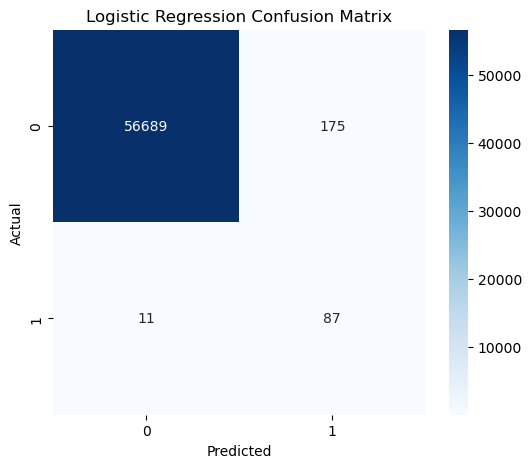

In [38]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

**Random Forest:**

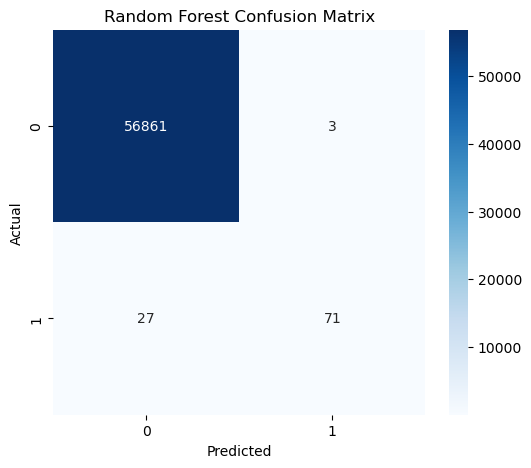

In [39]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## Precision vs Recall

* In fraud detection, Recall is often highly important because it measures the proportion of actual fraudulent transactions that are successfully detected. A false negative means a fraudulent transaction is incorrectly classified as legitimate, which can cause financial losses. However, precision is also important because a very low precision produces many false alerts and can inconvenience legitimate customers. Therefore, a practical fraud detection system should optimize the precision-recall trade-off according to the business cost of false negatives and false positives.

## ROC-AUC Curve

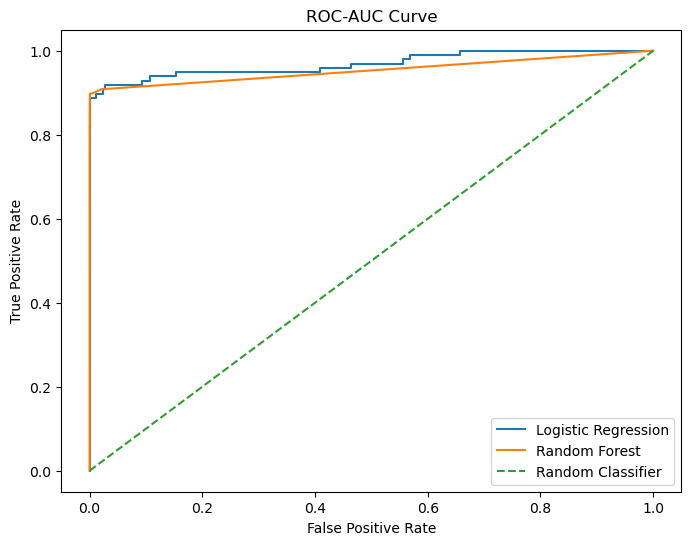

In [40]:
fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label='Logistic Regression'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label='Random Forest'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC-AUC Curve')

plt.legend()

plt.show()

## Feature Importance

In [41]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=x.columns
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

feature_importance.head(10)

V14    0.197558
V10    0.143384
V12    0.094905
V4     0.091428
V11    0.078254
V17    0.067856
V3     0.047709
V16    0.029455
V7     0.028795
V2     0.023861
dtype: float64

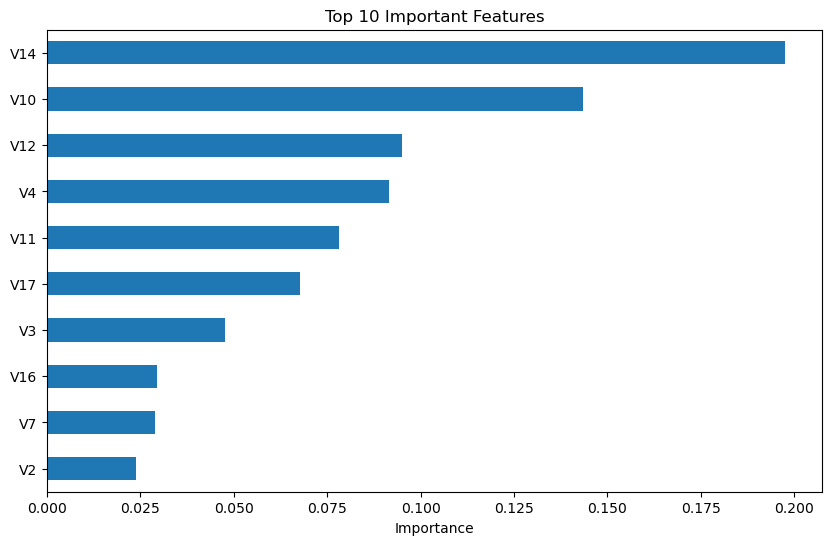

In [42]:
plt.figure(figsize=(10,6))

feature_importance.head(10).sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Important Features')
plt.xlabel('Importance')

plt.show()

## Logistic Regression coefficient analysis

In [43]:
coefficients = pd.Series(
    lr_model.coef_[0],
    index=x.columns
)

coefficients = coefficients.sort_values(
    key=abs,
    ascending=False
)

coefficients.head(10)

V4      1.424982
V10    -0.873206
Time   -0.809178
V14    -0.601129
Hour    0.490297
V5      0.479826
V13    -0.457570
V16    -0.438053
V12    -0.437046
V1      0.427877
dtype: float64

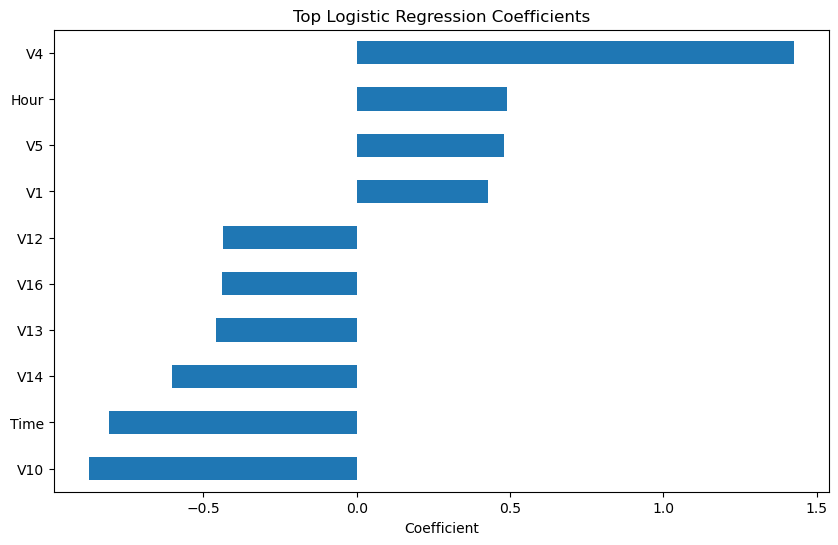

In [44]:
plt.figure(figsize=(10,6))

coefficients.head(10).sort_values().plot(
    kind='barh'
)

plt.title('Top Logistic Regression Coefficients')
plt.xlabel('Coefficient')

plt.show()

## Classification report

In [45]:
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.33      0.89      0.48        98

    accuracy                           1.00     56962
   macro avg       0.67      0.94      0.74     56962
weighted avg       1.00      1.00      1.00     56962



In [46]:
print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.72      0.83        98

    accuracy                           1.00     56962
   macro avg       0.98      0.86      0.91     56962
weighted avg       1.00      1.00      1.00     56962



## Final Conclusion

* This project developed a machine-learning pipeline for credit-card fraud detection using a highly imbalanced dataset containing 284,807 transactions and 492 fraudulent transactions. Exploratory analysis demonstrated the extreme class imbalance and differences in transaction characteristics.

* Because accuracy can be misleading for this problem, Precision, Recall, F1-Score and ROC-AUC were used as the primary evaluation metrics. Stratified train/test splitting was applied to ensure fraud cases were represented in both datasets.

* "SMOTE" was applied to the training data to address class imbalance, and Logistic Regression was trained using the resampled data. A Random Forest model using class weighting was also trained for comparison.

* Logistic Regression achieved higher recall, making it useful when detecting as many fraudulent transactions as possible is the primary objective.Random Forest provided substantially higher precision and a stronger F1-Score in the experiment, providing a better overall balance between detecting fraud and limiting false alerts.

* For production deployment, the model threshold should be optimized according to the business cost of false positives and false negatives. For large-scale deployment, the system could be implemented using scalable real-time model serving and parallel processing to handle approximately 1 million transactions per hour.